In [1]:
# plan:
# for each timestep:
#     load training data
#     load test data
#     project
#     for each sigma:
#         for each kernel:
#             smoothen
#             build ROM
#             sharpen
#             calculate test error
#     load validation data
#     calculate validation error
# box plot error over time
# plot sigma over time
# plot k_s over time

In [30]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding, smoothen, remove_wall, threshold)
from smooth_POD_ROM.post_processing import sharpen
from smooth_POD_ROM.io import get_data, get_field
from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
import tvtk
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (page_width_in/2, page_width_in/3)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 25

8.030570172000001


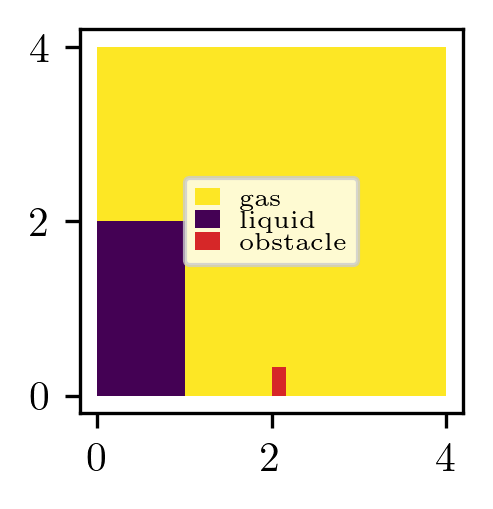

In [18]:
domain = np.array([
    [0, 0, 0],
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
    [4, 0, 0],
    [4, 4, 0],
    [0, 4, 0],
])
water = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 2, 0],
    [0, 2, 0],
])
obstacle = np.array([
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
])

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.fill(domain[:, 0], domain[:, 1], "#FDE725FF", alpha=1, label="gas")
plt.fill(water[:, 0], water[:, 1], "#440154FF", alpha=1, label="liquid")
plt.fill(obstacle[:, 0], obstacle[:, 1], "C3", alpha=1, label="obstacle")
ax.set_aspect("equal")
plt.legend()
plt.show()

In [5]:
mypath = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk" + \
        "/Documents/data/damBreak_results/"
mypath = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results/"
rank = 80
size_p_test = 10
timestep = 0.3

In [28]:
def plot_dam_snapshot(ax, ss, X, Y):
    cmap = plt.cm.viridis_r
    cmap.set_under('C3')
    x = np.unique(X)
    dx = x[1]-x[0]
    y = np.unique(Y)
    dx = y[1]-y[0]
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dx/2, np.max(y)+dx/2)
    cs = ax.imshow(ss.T, origin="lower", interpolation="nearest", extent=extent, cmap=cmap)
    return cs

In [7]:
def get_data(pth, nu_all, rho_all, timesteps=np.linspace(0.01, 1, 100)):
    if len(nu_all) == 0:
        return np.empty((100, 0)), np.empty((0, 2)), np.empty((0, 0))
    X = []
    params = []
    for n, r in zip(nu_all, rho_all):
        for ts in timesteps:
            file = "damBreak_m{:02.1f}_r{:02.1f}_t{:.2f}/internal.vtu".format(n, r, ts)
            data = get_field(pth+file, 'alpha.water')
            X.append(data)
            params.append([n, r, ts])
    if len(timesteps) == 1:
        params = np.array(params)[:, :2]
    snapshots3D = np.array(X).T
    
    points3D = get_field(pth+file, 'points')
    forbidden_points = points3D[:, 2] > 0.0
    snapshots = snapshots3D[~forbidden_points, :]
    points = points3D[~forbidden_points, :2]
    return snapshots, params, points

In [8]:
# the training data is defined on a regular grid defined as:
nu_grid = 10*2**np.arange(0, 10, 1)
rho_grid = 10*2**np.arange(0, 8, 1)
nu_train, rho_train = np.meshgrid(nu_grid, rho_grid, indexing="ij")
nu_train, rho_train = nu_train.ravel(), rho_train.ravel()

In [9]:
# the test and validation data are 100 simulations for random parameters

# 1. locate files and parse nu and rho:
onlyfiles = [f for f in listdir(mypath) if f.endswith(".series")]

nu_rand, rho_rand = np.array([]), np.array([])
for f in onlyfiles:
    m, r = re.findall(r"[-+]?\d*\.\d+|\d+", f)
    if float(m) not in nu_grid and float(r) not in rho_grid:
        nu_rand = np.append(nu_rand, float(m))
        rho_rand = np.append(rho_rand, float(r))

# 2. split into test and validation data
indices_shuffled = np.arange(len(nu_rand))
np.random.shuffle(indices_shuffled)

nu_test = nu_rand[indices_shuffled[:size_p_test]]
rho_test = rho_rand[indices_shuffled[:size_p_test]]
nu_val = nu_rand[indices_shuffled[size_p_test:]]
rho_val = rho_rand[indices_shuffled[size_p_test:]]

In [10]:
u_train, p_train, points = get_data(mypath, nu_train, rho_train, timesteps=[timestep])

In [11]:
u_test, p_test, points = get_data(mypath, nu_test, rho_test, timesteps=[timestep])

In [12]:
u_val, p_val, _ = get_data(mypath, nu_val, rho_val, timesteps=[timestep])

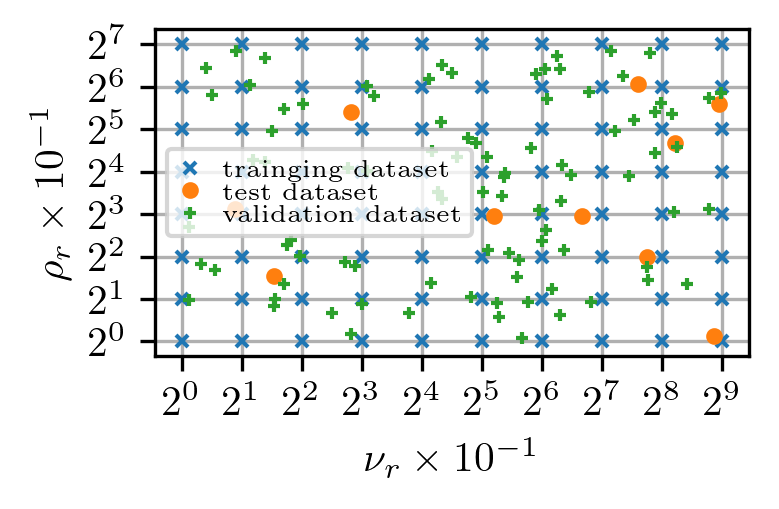

In [13]:
fig, ax = plt.subplots()
plt.plot(nu_train, rho_train, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
plt.plot(nu_test, rho_test, lw=0.0, color='C1', marker='o', ms=3, label="test dataset")
plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid))
ax.set_xticklabels(nu_grid)
ax.set_yticklabels(rho_grid)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid)
ax.set_yticks(rho_grid)
ax.set_xticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 10, 1)])
ax.set_yticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 8, 1)])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)

ax.legend()
plt.grid(True)
plt.show()

In [14]:
#X, Y, test_snapshot = on_regular_grid(points,  u_train[:, 0])
#m, n = u_train.shape
n_x = n_y = 256
x = np.linspace(0, 0.584, n_x, endpoint=True)
y = np.linspace(0, 0.584, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
is_wall = (0.292 <= X) & (X <= 0.316) & (Y <= 0.048)

u_train_grid = np.empty((n_x*n_y, u_train.shape[1]))
u_test_grid = np.empty((n_x*n_y, u_test.shape[1]))
u_val_grid = np.empty((n_x*n_y, u_val.shape[1]))

for u_set, u_set_grid in zip([u_train, u_test, u_val], [u_train_grid, u_test_grid, u_val_grid]):
    for j in range(u_set.shape[1]):
        gridded = griddata(points[:, :2], u_set[:, j], (X, Y), method="nearest")
        gridded = threshold(gridded)
        gridded[is_wall] = .5
        u_set_grid[:, j] = gridded.ravel()
gridded_shape = gridded.shape

In [15]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_test).T
for j in range(len(p_test)):
    u_ROM[:, j] = threshold(u_ROM[:, j])
    rmw = u_ROM[:, j].reshape(gridded_shape)
    rmw[is_wall] = .5
    u_ROM[:, j] = rmw.ravel()

e_ROM = np.mean((u_ROM-u_test_grid)**2, axis=0)**.5

In [16]:
from datetime import datetime

In [19]:
u_train_smooth = np.zeros_like(u_train_grid)

sigmas = np.linspace(0, 10, 41)
n_sharpenings = [1, 2, 3]
size_filter = [1, 3, 5, 7, 9, 11]
n_sharpenings = [1]
size_filter = [1, 3, 5, 7]


e_sROMs = np.zeros((len(sigmas), len(size_filter), len(n_sharpenings), size_p_test))

for i, sgm in enumerate(sigmas):
    print(i, end=", ")
    for j in range(u_train_grid.shape[1]):
        ss2D = u_train_grid[:, j].reshape(gridded_shape)
        u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD(rank=rank)
    db = Database(p_train, u_train_smooth.T)
    rom = ROM(db, pod, reg)
    rom.fit()
    u_sROM = rom.predict(p_test).T


    for k, sz in enumerate(size_filter):
        for l, ns in enumerate(n_sharpenings):
            p_sharp = np.zeros_like(u_test_grid)
            for j in range(len(p_test)):
                p_sharp[:, j] = sharpen(u_sROM[:, j].copy().reshape(gridded_shape), sz, ns)
                t2 = datetime.now()
                p_sharp[:, j] = threshold(p_sharp[:, j])
                rmw = p_sharp[:, j].reshape(gridded_shape)
                rmw[is_wall] = .5
                p_sharp[:, j] = rmw.ravel()
            e_sROMs[i, k, l] = np.mean((p_sharp-u_test_grid)**2, axis=0)**.5

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 

size= 3 k= 1 sigma= 1.0 ns= 1 e= 0.058338875437258166
size= 5 k= 2 sigma= 2.5 ns= 1 e= 0.06177970645662252
size= 7 k= 3 sigma= 3.5 ns= 1 e= 0.06293558001082854
4 1 0
1.0 3 1


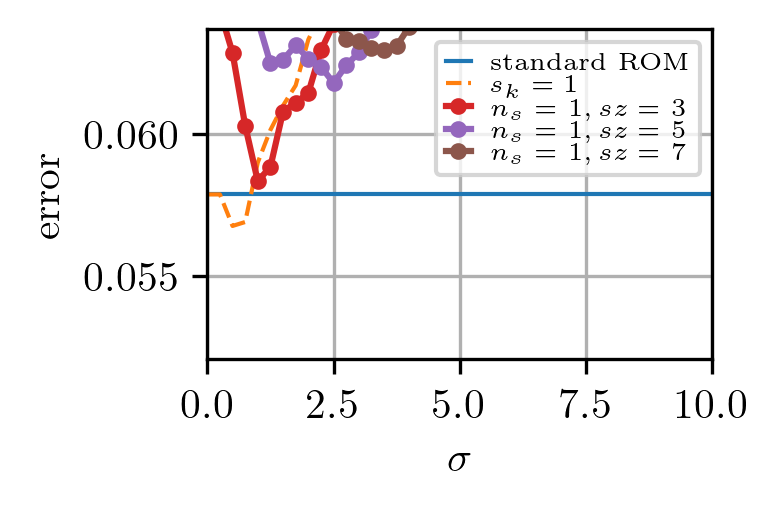

In [20]:
#plt.plot(sigmas, e2, label="smooth ROM")
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(sigmas, np.ones_like(sigmas)*np.mean(e_ROM), lw=1, label="standard ROM")
colors = ["C2", "C3", "C4", "C5", "C6"]
marker = [".", "1", "+", "x", "|", "_", "0"]
plt.plot(sigmas, np.mean(e_sROMs[:, 0, 0], axis=1), "C1--", lw=1, label="$s_k=1$")
for k, sz in enumerate(size_filter):
    #sz = size_filter[k]
    if k in [1, 2, 3, 4]:
        l = 0
        #plt.plot(sigmas, e_sROMs[:, k, 0], color=colors[k], marker=marker[k], ms=4, ls="-", lw=1, label="$s_k=${:2d}".format(sz))
        plt.plot(sigmas, np.mean(e_sROMs[:, k, 0], axis=1), color=colors[k], marker="o", ms=3, ls="-", label="$n_s = ${:2d}$, sz=${:2d}".format(1, sz))
        #plt.plot(sigmas, np.mean(e_sROMs[:, k, 1], axis=1), color=colors[k], marker="X", ms=3, ls="--", label="$n_s = ${:2d}$, sz=${:2d}".format(2, sz))
        #plt.plot(sigmas, np.mean(e_sROMs[:, k, 2], axis=1), color=colors[k], marker="+", ms=3, ls=":", label="$n_s = ${:2d}$, sz=${:2d}".format(3, sz))
        # plt.plot(sigmas, np.max(e_sROMs[:, k, 0], axis=1), color=colors[k], marker="o", ms=3, ls="-", label="$n_s = ${:2d}$, sz=${:2d}".format(1, sz))
        # plt.plot(sigmas, np.min(e_sROMs[:, k, 1], axis=1), color=colors[k], marker="X", ms=3, ls="--", label="$n_s = ${:2d}$, sz=${:2d}".format(2, sz))
        # plt.plot(sigmas, np.min(e_sROMs[:, k, 2], axis=1), color=colors[k], marker="+", ms=3, ls=":", label="$n_s = ${:2d}$, sz=${:2d}".format(3, sz))
        ind = np.argmin(np.mean(e_sROMs[:, k, l], axis=1))
        print("size=", sz, "k=",k,"sigma=", sigmas[ind], "ns=", 1, "e=", np.mean(e_sROMs[ind, k, l, :]))
plt.legend()
# plt.ylim([0.015, .025])
# plt.ylim([0.03, .04])
#plt.ylim([0.015, .02])
plt.ylim([np.min(np.mean(e_sROMs, axis=-1))*0.95, np.mean(e_ROM)*1.1])
plt.ylim([np.mean(e_ROM)*0.9, np.mean(e_ROM)*1.1])
plt.xlim([0, 10])
plt.xlabel("$\sigma$")
plt.ylabel("error")
plt.grid()

k, l = 1, 0
i = np.argmin(np.mean(e_sROMs[:, k, l], axis=-1))
sgm = sigmas[i]
sz = size_filter[k]
ns = n_sharpenings[l]
print(i, k, l)
print(sgm, sz, ns)

In [ ]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_val).T

e_ROM = np.mean((u_ROM-u_val_grid)**2, axis=0)**.5


for j in range(u_train_grid.shape[1]):
    ss2D = u_train_grid[:, j].reshape(gridded_shape)
    u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_smooth.T)
rom = ROM(db, pod, reg)
rom.fit()
u_sROM = rom.predict(p_val).T

p_sharp = np.zeros_like(u_sROM)
for j in range(len(p_val)):
    #print(eror_sROMs[j], (e_sROMs/e_ROM)[j])
    p_sharp[:, j] = sharpen(u_sROM[:, j].copy().reshape(gridded_shape), sz, ns)
    p_sharp[:, j] = threshold(p_sharp[:, j])
    rmw = p_sharp[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    p_sharp[:, j] = rmw.ravel()
    if j < 10:
        fig, (ax1, ax3, ax4) = plt.subplots(1, 3, figsize=(5, 15))
        cs1 = plot_dam_snapshot(ax1, u_test_grid[:, j].reshape(gridded_shape), X, Y)
        #plot_dam_snapshot(ax2, 1-u_sROM[:, j].reshape(gridded_shape), X, Y)
        #ax2.imshow(u_sROM[:, j].reshape(gridded_shape).T, origin="lower")
        cs3 = plot_dam_snapshot(ax3, u_ROM[:, j].reshape(gridded_shape), X, Y)
        cs4 = plot_dam_snapshot(ax4, p_sharp[:, j].reshape(gridded_shape), X, Y)

        ax3.text(50, 50, "e={:.3f}".format(np.mean((u_ROM[:, j]-u_val_grid[:, j])**2)**.5))
        ax4.text(50, 50, "e={:.3f}".format(np.mean((p_sharp[:, j]-u_val_grid[:, j])**2)**.5))
        for ax, cs in zip([ax1, ax3, ax4], [cs1, cs3, cs4]):
            ax.set_xticks([])
            ax.set_yticks([])
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(cs, cax=cax)
        plt.show()
eror_sROMs = np.mean((p_sharp-u_val_grid)**2, axis=0)**.5
print(e_ROM)
print(eror_sROMs)
print(eror_sROMs/e_ROM)


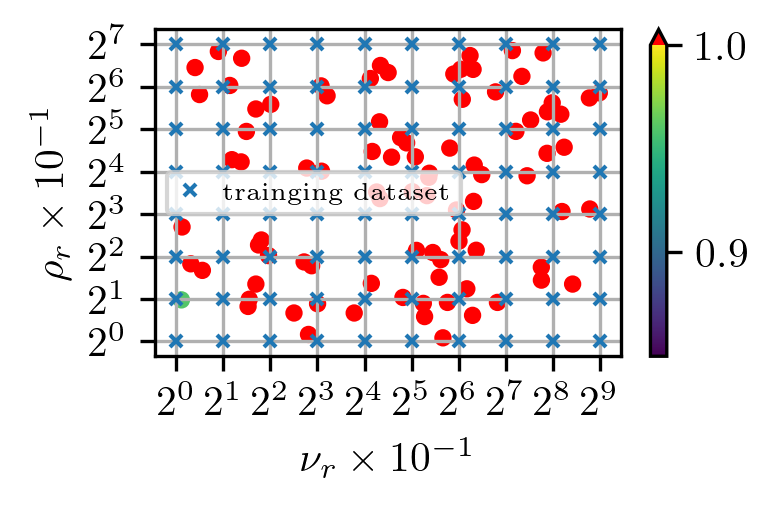

In [38]:
fig, ax = plt.subplots()
plt.plot(nu_train, rho_train, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
cmap = plt.cm.viridis
cmap.set_over('red')

cs = plt.scatter(nu_val, rho_val, c=eror_sROMs/e_ROM, vmin=0.85, vmax=1.0, s=10, cmap=cmap)
plt.colorbar(cs, extend='max')
#plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid))
ax.set_xticklabels(nu_grid)
ax.set_yticklabels(rho_grid)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid)
ax.set_yticks(rho_grid)
ax.set_xticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 10, 1)])
ax.set_yticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 8, 1)])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)

ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
plt.savefig("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/t{:.2f}_{:d}testss_sgm{:.1f}_sz{:d}_256x256.png".format(timestep, size_p_test, sgm, sz))
plt.show()